# Predicting accessibility with DeepDanio

This notebook shows how to use DeepDanio to predict chromatin accessibility of a DNA sequence across 95 zebrafish embryonic cell states, from the high stage to the 6-somite stage, and how to visualize these predictions.

Steps:
1. Choose a model and an input sequence, either a genomic region or a sequence of your own.
2. Load the model and extract the sequence.
3. Predict accessibility in every cell state.
4. Plot predictions grouped by developmental stage, and along the cell state differentiation trajectory.

Requirements:
- Model weights, downloaded with `models/download_weights.py`.
- The reference genome, downloaded with `data/download_data.py`, only if predicting on a genomic region.

## Imports

`deepdanio` modules used here:
- `definitions`: paths to model files and data, and cell state information such as `CELL_STATES`, the names of the model outputs.
- `genome`: loads the reference genome and extracts sequences from genomic coordinates.
- `model`: loads trained models and builds model ensembles.
- `sequence`: one-hot encodes sequences, the input format of the model.
- `plot`: plotting functions for values across cell states.

In [1]:
import json
import warnings

import pandas
from matplotlib import pyplot

from deepdanio import definitions, genome, model, plot, sequence

## Settings

Edit this cell to choose the model and the input sequence.

- `MODEL`: which model to use.
  - `'ensemble'` (recommended) averages the predictions of the models trained on chromosome splits 0, 1, and 2.
  - `0`, `1`, or `2` uses only the model trained on that split. Each model never saw the chromosomes of its test set during training, so a single model can be used to obtain predictions on sequences the model has not seen, e.g. to evaluate the model on native sequences. The chromosomes in each set are shown when loading the model.
- `REGION`: genomic region in the GRCz11 genome, as `'chr:start-end'` (e.g. `'chr12:30753644-30754144'`), with zero-based, half-open coordinates. Commas in coordinates are allowed. The model takes 500 bp sequences, so for regions of a different length the 500 bp window centered on the region is used, with a warning.
- `SEQUENCE`: a DNA sequence of your own, e.g. a designed enhancer. If specified, `REGION` is ignored. Sequences longer than 500 bp are trimmed to their central 500 bp, with a warning. Shorter sequences raise an error.

The default region is a peak on chromosome 12 that is most accessible in the yolk syncytial layer (YSL) around 50% epiboly. Chromosome 12 is in the test set of split 0, so setting `MODEL = 0` shows the prediction of a model that did not see this sequence during training.

In [2]:
MODEL = 'ensemble'
REGION = 'chr12:30753644-30754144'
SEQUENCE = None

## Load model

Loads the model selected in `MODEL`. An ensemble is built as a single model that runs the input through each of the split models and averages their outputs. Ensembles can also take the minimum or maximum across models for specific outputs, see `model.make_model_ensemble`.

If a single split is selected, the chromosomes used to train, validate, and test that model are printed. Predictions on sequences from the test chromosomes are not influenced by training on those sequences.

Loading the model only needs to be done once. To predict on a different sequence with the same model, rerun the cells from "Get sequence" onwards.

In [3]:
if MODEL == 'ensemble':
    model_paths = list(definitions.DEEPDANIO_MODEL_PATHS.values())
    keras_model = model.make_model_ensemble([str(p) for p in model_paths])
    print(f"Loaded ensemble of {len(model_paths)} models.")
else:
    keras_model = model.load_model(definitions.DEEPDANIO_MODEL_PATHS[MODEL])
    print(f"Loaded model for split {MODEL}.")

    # Show which chromosomes this model was trained, validated, and tested on
    with open(definitions.CHR_SPLITS_PATH) as f:
        chr_split = json.load(f)[MODEL]
    for subset in ['train', 'val', 'test']:
        print(f"{subset}: {', '.join(chr_split[subset])}")

Loaded ensemble of 3 models.


## Get sequence

Gets the 500 bp input sequence from the settings above:
- If `SEQUENCE` is `None`, the region in `REGION` is parsed, centered to 500 bp if necessary, and its sequence is extracted from the genome. Only the chromosome of the region is loaded, which is faster than loading the whole genome.
- Otherwise, `SEQUENCE` is used, centered to 500 bp if necessary.

The sequence may only contain the bases A, C, G, T, and N (any base), in upper or lower case. `seq_name` is used as the title of the plots below.

In [4]:
if SEQUENCE is None:
    # Parse region
    chrom, coords = REGION.split(':')
    start, end = [int(c.replace(',', '')) for c in coords.split('-')]

    # Use the window centered on the region if its length is different
    region_length = end - start
    if region_length != definitions.SEQ_LENGTH:
        start = (start + end) // 2 - definitions.SEQ_LENGTH // 2
        end = start + definitions.SEQ_LENGTH
        warnings.warn(
            f"Region is {region_length} bp long. "
            f"Using the centered {definitions.SEQ_LENGTH} bp window {chrom}:{start}-{end}."
        )
    seq_name = f'{chrom}:{start}-{end}'

    # Load only the necessary chromosome
    genome_seqs = genome.load_genome([chrom])
    seq = genome.get_sequence(genome_seqs, chrom, start, end)
else:
    seq = SEQUENCE.upper()
    if len(seq) < definitions.SEQ_LENGTH:
        raise ValueError(f"Sequence must be at least {definitions.SEQ_LENGTH} bp long, got {len(seq)} bp.")

    # Use the central portion if longer
    if len(seq) > definitions.SEQ_LENGTH:
        seq_start = (len(seq) - definitions.SEQ_LENGTH) // 2
        warnings.warn(
            f"Sequence is {len(seq)} bp long. Using the centered {definitions.SEQ_LENGTH} bp, "
            f"starting at position {seq_start}."
        )
        seq = seq[seq_start:seq_start + definitions.SEQ_LENGTH]
    seq_name = 'Input sequence'

invalid_bases = set(seq) - set('ACGTN')
if invalid_bases:
    raise ValueError(f"Sequence contains invalid characters: {invalid_bases}")

print(seq)

TTATCTTAGGAGGAGTTATCTGTTGGAAAAACCCTGAAAAAATGTGTTATTCGGGAAAAGCTCTAAATGACAATATTTAAATGAATAAGCCCTGGCGATAGTTAATCAAAATCGTCTTTTGTTAGATGATGTATTTACTGGTTTGAGGGCGAAACAGTCATTTACTCTATTGAGATGATCAAGAGTAACCACAATCATCCATTGATCCAATCAATTCATGACAAACATCAAGTTCTGTCCTACATGTTTCTATTGTTTGAGAAGCCATTTCACATCAGATATGCATCACATTGATTATTGTGCCTATTGTAAAGCCACAATATACCTTTAAAGTAATCAGATAAACTTTTGTGACGACATGTCACAAAATCAAGCCAAAATAAAGTTGTTAAAAATAGTTTTAGAAGTTCAAATCAAATTAAAAAGTGAACTGTTCCAGATGAGTGGGCATCTTTTTGGAAATACCTTTGAACAACCATTAGTCAGTGGTGATTATGCAA


## Predict

The sequence is one-hot encoded and passed to the model, which outputs one value per cell state. Predictions are stored as a pandas Series indexed by cell state name, in the order of `definitions.CELL_STATES`.

Predicted values are in the same units as the training data: log10-transformed CPM, quantile normalized across cell states. Higher values indicate higher accessibility. Quantile normalization gives all cell states the same distribution of values, with a minimum of about -0.56. The model was trained to predict this minimum for random genomic sequences, so predictions close to it (below about -0.2) indicate an inaccessible sequence.

The cell below shows the 10 cell states with the highest predictions. Change or remove `.head(10)` to show more, or use `pred[cell_state]` to get the prediction for a specific cell state. To save predictions, use e.g. `pred.to_csv('predictions.csv')`.

In [5]:
pred = keras_model.predict(sequence.one_hot_encode([seq]), verbose=0)[0]
pred = pandas.Series(pred, index=definitions.CELL_STATES, name='prediction')
pred.sort_values(ascending=False).head(10)

ysl(50epi)          1.434228
ysl(shield)         1.337562
ysl(30epi)          1.207350
ysl(75epi)          0.965275
ysl(dome)           0.740369
ysl(bud)            0.523370
ysl(6somite)        0.189205
evl(50epi)         -0.236839
endoderm(shield)   -0.244967
evl(dome)          -0.249323
Name: prediction, dtype: float32

## Plot

### Bar plot

`plot.bar` shows one bar per cell state, grouped by developmental stage (separated by dashed lines and labeled on top) and colored by lineage (neural ectoderm, non-neural ectoderm, mesoderm, endoderm, YSL, EVL, or other).

Arguments to customize the plot:
- `cell_states`: list of cell states to plot, e.g. a subset, in the given order. Values must be given in the same order. Cell states should be grouped by stage for stage labels to make sense.
- `cell_state_colors`: dictionary of bar color for each cell state, replacing the lineage colors.
- `width`: bar width.
- `ylim`: y axis limits, e.g. to compare plots of different sequences on the same scale.
- `stage_title_fontsize`, `stage_title_y_offset`: font size and vertical position of the stage labels.
- `figsize`, or `ax` to draw on existing axes, e.g. to combine several plots in one figure.

Values can also be a 2D array with one row per sample. In that case, bars show the mean and error bars the standard deviation, e.g. to show the spread of predictions of the individual split models.

The function returns the matplotlib axes, which can be further customized, e.g. with `ax.set_ylabel` as below. To save the figure, use `ax.figure.savefig('bar.png', bbox_inches='tight')`.

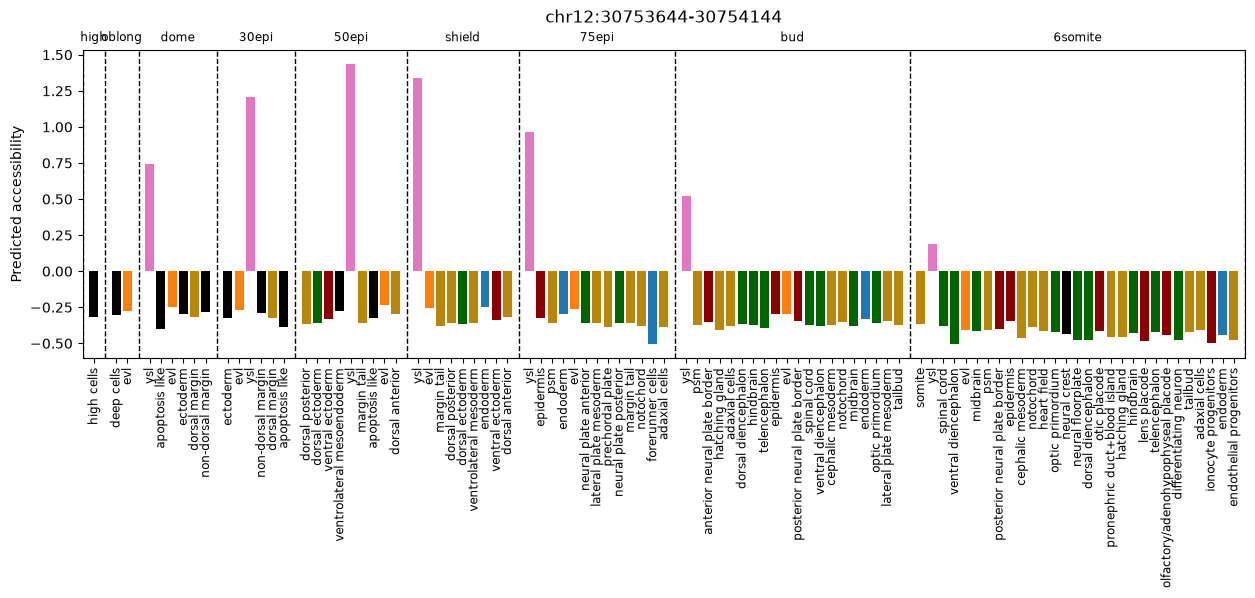

In [6]:
ax = plot.bar(pred, figsize=(15, 4))
ax.set_ylabel('Predicted accessibility')
ax.set_title(seq_name, pad=20)
pyplot.show()

### Trajectory plot

`plot.trajectory` shows cell states as dots along the differentiation trajectory, from the high stage (left) to the 6-somite stage (right), colored by predicted accessibility. Lines connect cell states to their descendants, with opacity indicating the probability of each connection. Stages are labeled at the bottom.

Arguments to customize the plot:
- Colors:
  - `cmap`: name of a matplotlib colormap (e.g. `'magma'`, `'Reds'`) or a colormap object.
  - `vmin`, `vmax`: values mapped to the ends of the colormap. By default, the minimum and maximum of the predictions. Fix them to compare plots of different sequences on the same scale.
  - `colorbar`, `colorbar_label`: whether to draw a colorbar to the right of the plot, and its label.
  - `shade_edges`: if `True` (default), lines are colored with a gradient between the colors of the cell states they connect. If `False`, lines are black.
  - Without `cell_state_vals`, dots are colored by lineage, or by `cell_state_colors` (a dictionary of colors for each cell state).
- Labels:
  - `cell_state_labels`: `'final'` labels the cell states of the last stage, `'all'` labels every cell state, and `None` shows no labels.
  - `stage_labels`: whether to label stages at the bottom.
  - `cell_state_label_size`, `stage_label_size`: font sizes.
- Size: `markersize` (dot size), `linewidth` (line width), and `figsize`, or `ax` to draw on existing axes.

The colorbar and the cell state labels are drawn outside the axes. When combining several plots in one figure, leave space between them, e.g. with `pyplot.subplots(..., gridspec_kw={'wspace': 0.7})`, and use `bbox_inches='tight'` when saving, e.g. `fig.savefig('trajectory.png', bbox_inches='tight')`.

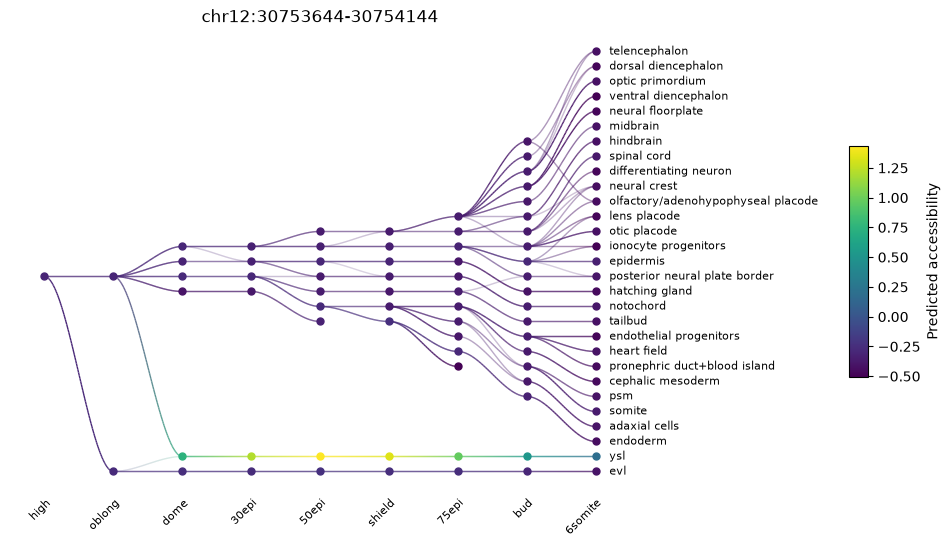

In [7]:
fig, ax = pyplot.subplots(figsize=(8, 6))
plot.trajectory(
    cell_state_vals=pred,
    cmap='viridis',
    colorbar=True,
    colorbar_label='Predicted accessibility',
    cell_state_labels='final',
    ax=ax,
)
ax.set_title(seq_name)
pyplot.show()